# 18a — ADR Forecasting for Dynamic Pricing (statsmodels)

Forecast **ADR theo tháng** bằng **statsmodels** trên `hotel_bookings_v5.csv`, theo Workflow 4 (Time Series Forecasting) của skill `statsmodels`:

1. Plot series + seasonality  
2. Stationarity tests (**ADF**, **KPSS**)  
3. ACF / PACF để gợi ý bậc  
4. Fit **SARIMAX** (chọn order bằng AIC/BIC) + **Holt–Winters**  
5. Residual diagnostics (`plot_diagnostics`, Ljung–Box)  
6. Forecast có **prediction intervals**  
7. Holdout accuracy vs **Seasonal Naive** baseline  

**Phạm vi:** monthly mean ADR (stay bookings, adr > 0) · chuỗi ~26 tháng (2015-07 → 2017-08) · đơn vị € / night.

**Công thức project (notebook 01):** `RevPAR = ADR × Occupancy_Rate`  
(Occupancy_Rate = tỷ lệ booking thành công theo nhóm thời gian — proxy, không phải inventory thật).

In [1]:
import os
import warnings
from itertools import product
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display as ipy_display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "18_adr"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
SEASON = 12
HOLDOUT = 6
METRIC = "adr"  # adr | revpar
METRIC_LABEL = "ADR"
YLABEL = "ADR (€)"

print(f"statsmodels {sm.__version__}")
print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")
print(f"Target metric: {METRIC_LABEL}")

statsmodels 0.14.6
ROOT: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\18_adr
Target metric: ADR


In [2]:
def fmt_num(n, d: int = 1) -> str:
    return f"{float(n):,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def savefig(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))


def load_monthly_metric(metric: str) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """Build monthly overall series + by-hotel series.

    ADR: mean(adr) on completed stays with adr > 0.
    RevPAR: ADR_month × Occupancy_month, with
      Occupancy = share of non-canceled bookings (project proxy).
    Also keep hotel-month RevPAR from dataset column for cross-check.
    """
    df = pd.read_csv(DATA_PATH)
    df["month_num"] = df["arrival_date_month"].map(MONTH_MAP)
    df["ym"] = pd.to_datetime(
        dict(year=df["arrival_date_year"], month=df["month_num"], day=1)
    )

    stay = df[(df["is_canceled"] == 0) & (df["adr"] > 0)].copy()

    # Overall monthly ADR & occupancy proxy
    adr_overall = stay.groupby("ym")["adr"].mean().rename("adr")
    occ_overall = (1 - df.groupby("ym")["is_canceled"].mean()).rename("occupancy_rate")
    revpar_overall = (adr_overall * occ_overall).rename("revpar")

    panel = pd.concat([adr_overall, occ_overall, revpar_overall], axis=1).sort_index()
    panel = panel.asfreq("MS")

    # By hotel
    adr_h = stay.groupby(["hotel", "ym"])["adr"].mean().rename("adr").reset_index()
    occ_h = (
        (1 - df.groupby(["hotel", "ym"])["is_canceled"].mean())
        .rename("occupancy_rate")
        .reset_index()
    )
    by_hotel = adr_h.merge(occ_h, on=["hotel", "ym"], how="inner")
    by_hotel["revpar"] = by_hotel["adr"] * by_hotel["occupancy_rate"]
    # Dataset column cross-check (hotel-month constant)
    ds = (
        df.groupby(["hotel", "ym"], as_index=False)
        .agg(revpar_dataset=("RevPAR", "first"), adr_dataset=("adr", "mean"))
    )
    by_hotel = by_hotel.merge(ds, on=["hotel", "ym"], how="left")

    if metric == "adr":
        y = panel["adr"].astype(float)
    elif metric == "revpar":
        y = panel["revpar"].astype(float)
    else:
        raise ValueError(metric)

    return y, by_hotel, panel


y, by_hotel, panel = load_monthly_metric(METRIC)
print(f"Months: {len(y)} | {y.index.min().date()} → {y.index.max().date()}")
print(f"Mean {METRIC_LABEL}: {fmt_num(y.mean(), 2)} | Min {fmt_num(y.min(), 2)} | Max {fmt_num(y.max(), 2)}")
display(panel.head(8).round(3))
if METRIC == "revpar":
    print("Formula check (first months): RevPAR ≈ ADR × Occupancy_Rate")
    chk = panel.copy()
    chk["adr_x_occ"] = chk["adr"] * chk["occupancy_rate"]
    display(chk[["adr", "occupancy_rate", "revpar", "adr_x_occ"]].head(6).round(4))

Months: 26 | 2015-07-01 → 2017-08-01
Mean ADR: 102,77 | Min 61,19 | Max 166,80


,adr,occupancy_rate,revpar
ym,,,
2015-07-01,122.738,0.694,85.224
2015-08-01,129.013,0.761,98.186
2015-09-01,105.131,0.802,84.263
2015-10-01,82.717,0.831,68.748
2015-11-01,61.190,0.849,51.924
2015-12-01,73.922,0.811,59.957
2016-01-01,63.791,0.834,53.215
2016-02-01,71.328,0.810,57.771


## 1. Plot series & seasonal decomposition

Saved: reports\figures\18_adr\01_monthly_adr_overall.png


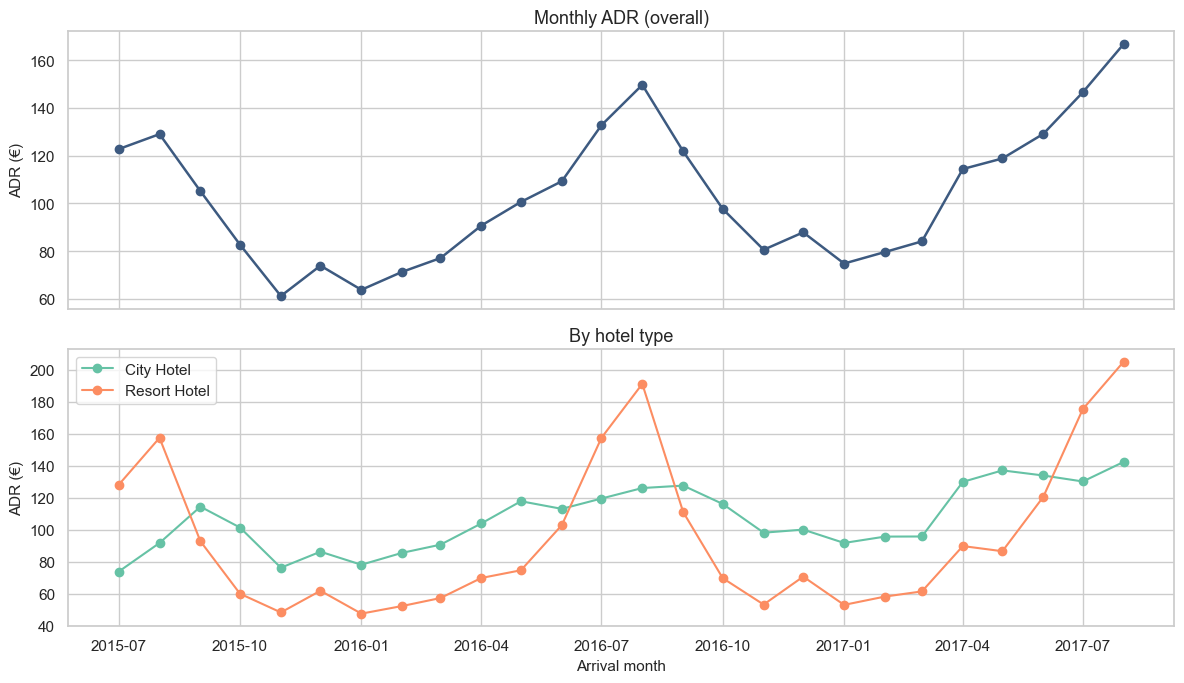

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(y.index, y.values, marker="o", lw=1.8, color="#3d5a80")
axes[0].set_ylabel(YLABEL)
axes[0].set_title(f"Monthly {METRIC_LABEL} (overall)")

col = "adr" if METRIC == "adr" else "revpar"
for hotel, g in by_hotel.groupby("hotel"):
    g = g.set_index("ym").sort_index()
    axes[1].plot(g.index, g[col], marker="o", label=hotel, lw=1.5)
axes[1].set_ylabel(YLABEL)
axes[1].set_title("By hotel type")
axes[1].legend()
axes[1].set_xlabel("Arrival month")
savefig(f"01_monthly_{METRIC}_overall.png")
plt.show()

**Insight — monthly ADR**

- Chuỗi ~**26 tháng** — forecast ngoài mẫu cần thận trọng (giống demand notebook 18).  
- Pattern mùa vụ thường mạnh hơn demand thuần: peak hè, đáy đông.  
- City vs Resort lệch biên độ → khi triển khai pricing nên xem calendar theo property.

Saved: reports\figures\18_adr\02_seasonal_decompose.png


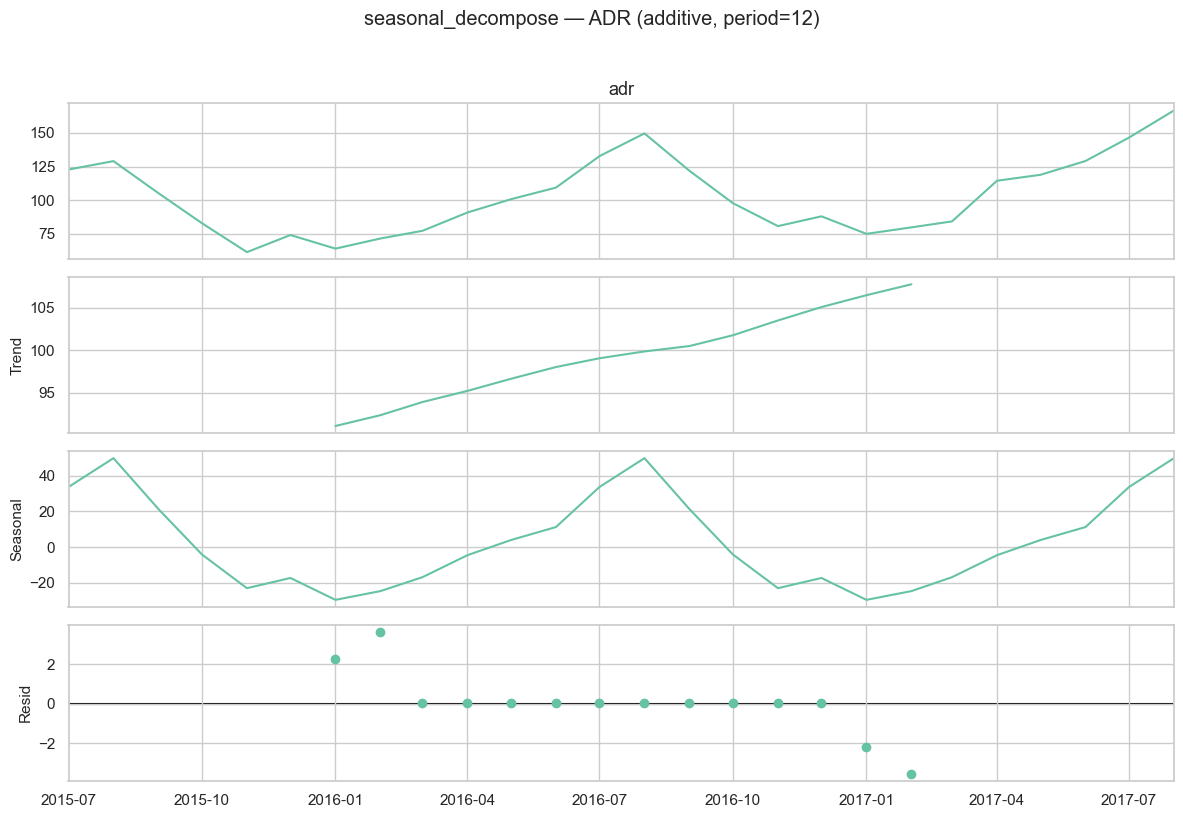

In [4]:
decomp = seasonal_decompose(y, model="additive", period=SEASON)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"seasonal_decompose — {METRIC_LABEL} (additive, period=12)", y=1.02)
savefig("02_seasonal_decompose.png")
plt.show()

## 2. Stationarity — ADF & KPSS

- **ADF** H₀: unit root → reject nếu p < 0.05  
- **KPSS** H₀: stationary → reject nếu p < 0.05  
- Kết hợp để chọn `d` / `D`

In [5]:
def stationarity_report(series: pd.Series, name: str) -> dict:
    series = series.dropna().astype(float)
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    except Exception as e:
        kpss_stat, kpss_p = np.nan, np.nan
        print(f"KPSS warning ({name}): {e}")
    return {
        "series": name,
        "n": len(series),
        "adf_stat": adf_stat,
        "adf_pvalue": adf_p,
        "adf_stationary_5pct": adf_p < 0.05,
        "kpss_stat": kpss_stat,
        "kpss_pvalue": kpss_p,
        "kpss_stationary_5pct": kpss_p >= 0.05 if pd.notna(kpss_p) else np.nan,
    }


candidates = {
    "level": y,
    "diff1": y.diff().dropna(),
    "seasonal_diff12": y.diff(SEASON).dropna(),
    "diff1_seasonal12": y.diff().diff(SEASON).dropna(),
}
stat_df = pd.DataFrame([stationarity_report(s, n) for n, s in candidates.items()])
display(stat_df.round(4))
stat_df.to_csv(FIG_DIR / "stationarity_tests.csv", index=False)


def pick_diff_orders(stat_df: pd.DataFrame) -> tuple[int, int]:
    for name, d, D in [
        ("diff1", 1, 0),
        ("seasonal_diff12", 0, 1),
        ("diff1_seasonal12", 1, 1),
        ("level", 0, 0),
    ]:
        row = stat_df.loc[stat_df["series"] == name].iloc[0]
        adf_ok = bool(row["adf_stationary_5pct"])
        kpss_ok = bool(row["kpss_stationary_5pct"]) if pd.notna(row["kpss_stationary_5pct"]) else False
        if adf_ok and kpss_ok:
            return d, D
    return 0, 1


d_order, D_order = pick_diff_orders(stat_df)
print(f"Selected differencing: d={d_order}, D={D_order} (s={SEASON})")

,series,n,adf_stat,adf_pvalue,adf_stationary_5pct,kpss_stat,kpss_pvalue,kpss_stationary_5pct
0,level,26,-0.1913,0.9395,False,0.2032,0.1,True
1,diff1,25,-3.7376,0.0036,True,0.2352,0.1,True
2,seasonal_diff12,14,-3.2087,0.0195,True,0.1061,0.1,True
3,diff1_seasonal12,13,-5.1370,0.0000,True,0.1896,0.1,True


Selected differencing: d=1, D=0 (s=12)

## 3. ACF / PACF (sau differencing đã chọn)

Saved: reports\figures\18_adr\03_acf_pacf.png


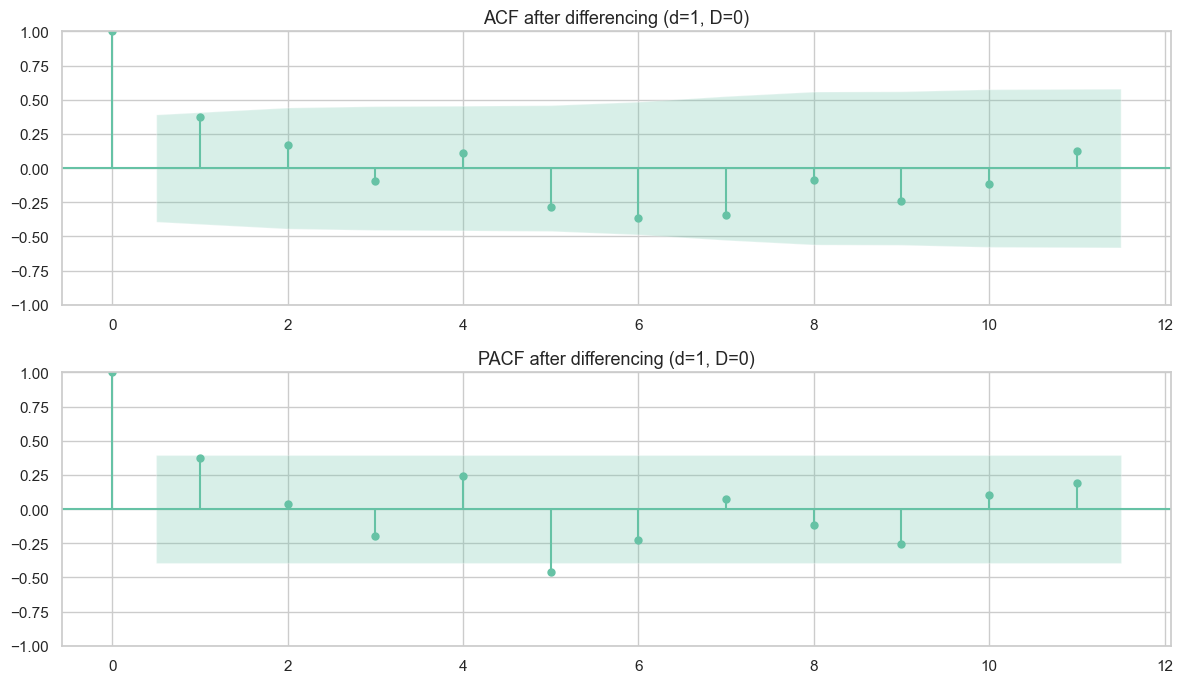

Rules of thumb: PACF cutoff → p; ACF cutoff → q; seasonal spikes at 12 → P/Q.


In [6]:
if D_order == 1 and d_order == 1:
    y_acf = y.diff().diff(SEASON).dropna()
elif D_order == 1:
    y_acf = y.diff(SEASON).dropna()
elif d_order == 1:
    y_acf = y.diff().dropna()
else:
    y_acf = y.copy()

max_lags = min(18, max(6, len(y_acf) // 2 - 1))
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y_acf, lags=max_lags, ax=axes[0])
axes[0].set_title(f"ACF after differencing (d={d_order}, D={D_order})")
plot_pacf(y_acf, lags=max_lags, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF after differencing (d={d_order}, D={D_order})")
savefig("03_acf_pacf.png")
plt.show()
print("Rules of thumb: PACF cutoff → p; ACF cutoff → q; seasonal spikes at 12 → P/Q.")

## 4. Model selection — SARIMAX grid (AIC/BIC) + Holt–Winters

Grid nhỏ vì n≈26: `p,q ∈ {0,1,2}`, `P,Q ∈ {0,1}`, `d,D` cố định từ stationarity.  
Baseline **Seasonal Naive** để so sánh holdout.

In [7]:
train = y.iloc[:-HOLDOUT]
test = y.iloc[-HOLDOUT:]
print(f"Train: {train.index.min().date()} → {train.index.max().date()} (n={len(train)})")
print(f"Test : {test.index.min().date()} → {test.index.max().date()} (n={len(test)})")


def fit_sarimax(series, order, seasonal_order):
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


grid_rows = []
for p, q, P, Q in product(range(0, 3), range(0, 3), range(0, 2), range(0, 2)):
    order = (p, d_order, q)
    seasonal_order = (P, D_order, Q, SEASON)
    if (p, d_order, q) == (0, 0, 0) and P == 0 and Q == 0:
        continue
    try:
        res = fit_sarimax(train, order, seasonal_order)
        aic_v, bic_v, llf_v = float(res.aic), float(res.bic), float(res.llf)
        if not np.isfinite(aic_v) or not np.isfinite(llf_v):
            continue
        grid_rows.append(
            {
                "order": str(order),
                "seasonal_order": str(seasonal_order),
                "p": p, "d": d_order, "q": q,
                "P": P, "D": D_order, "Q": Q,
                "aic": aic_v, "bic": bic_v, "llf": llf_v,
            }
        )
    except Exception:
        continue

grid = pd.DataFrame(grid_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
print(f"Fitted {len(grid)} usable SARIMAX candidates on train")
display(grid.head(10).round(2))
grid.to_csv(FIG_DIR / "sarimax_aic_grid.csv", index=False)
if len(grid) == 0:
    raise RuntimeError("No SARIMAX candidate fitted — relax grid or holdout.")

best = grid.iloc[0]
best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), SEASON)
print(
    f"Best SARIMAX by AIC: {best_order} x {best_seasonal} | "
    f"AIC={best['aic']:.2f} BIC={best['bic']:.2f}"
)
sarimax_train = fit_sarimax(train, best_order, best_seasonal)
print(sarimax_train.summary())

Train: 2015-07-01 → 2017-02-01 (n=20)
Test : 2017-03-01 → 2017-08-01 (n=6)


Fitted 36 usable SARIMAX candidates on train


,order,seasonal_order,p,d,q,P,D,Q,aic,bic,llf
0,"(2, 1, 2)","(1, 0, 1, 12)",2,1,2,1,0,1,23.09,18.79,-4.54
1,"(2, 1, 2)","(0, 0, 1, 12)",2,1,2,0,0,1,24.54,20.86,-6.27
2,"(0, 1, 2)","(1, 0, 1, 12)",0,1,2,1,0,1,29.14,26.08,-9.57
3,"(1, 1, 2)","(1, 0, 1, 12)",1,1,2,1,0,1,29.76,26.08,-8.88
4,"(0, 1, 1)","(1, 0, 1, 12)",0,1,1,1,0,1,30.01,28.44,-11.00
5,"(1, 1, 1)","(1, 0, 1, 12)",1,1,1,1,0,1,30.49,28.53,-10.24
6,"(2, 1, 0)","(1, 0, 0, 12)",2,1,0,1,0,0,31.36,29.80,-11.68
7,"(2, 1, 1)","(1, 0, 0, 12)",2,1,1,1,0,0,32.44,30.48,-11.22
8,"(2, 1, 2)","(1, 0, 0, 12)",2,1,2,1,0,0,33.23,30.89,-10.61
9,"(2, 1, 1)","(1, 0, 1, 12)",2,1,1,1,0,1,33.33,30.99,-10.66


Best SARIMAX by AIC: (2, 1, 2) x (1, 0, 1, 12) | AIC=23.09 BIC=18.79
                                      SARIMAX Results                                       
Dep. Variable:                                  adr   No. Observations:                   20
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 12)   Log Likelihood                  -4.543
Date:                              Mon, 20 Jul 2026   AIC                             23.086
Time:                                      09:05:04   BIC                             18.790
Sample:                                  07-01-2015   HQIC                            13.659
                                       - 02-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3617    114.

In [8]:
def fit_holt_winters(series: pd.Series, label: str = "series"):
    n = len(series)
    if n >= 2 * SEASON:
        model = ExponentialSmoothing(
            series, trend="add", seasonal="add",
            seasonal_periods=SEASON, initialization_method="estimated",
        )
        kind = "holt_winters_seasonal"
    else:
        print(f"[{label}] n={n} < {2 * SEASON}: seasonal HW unavailable -> Holt trend-only")
        model = ExponentialSmoothing(
            series, trend="add", seasonal=None, initialization_method="estimated",
        )
        kind = "holt_trend"
    return model.fit(optimized=True), kind


hw_train, hw_train_kind = fit_holt_winters(train, "train")
print(f"Train exponential smoothing kind: {hw_train_kind}")
print(hw_train.summary())

[train] n=20 < 24: seasonal HW unavailable -> Holt trend-only
Train exponential smoothing kind: holt_trend
                       ExponentialSmoothing Model Results                       
Dep. Variable:                      adr   No. Observations:                   20
Model:             ExponentialSmoothing   SSE                           4926.415
Optimized:                         True   AIC                            118.133
Trend:                         Additive   BIC                            122.116
Seasonal:                          None   AICC                           124.594
Seasonal Periods:                  None   Date:                 Mon, 20 Jul 2026
Box-Cox:                          False   Time:                         09:05:04
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smooth

## 5. Residual diagnostics (train fit)

plot_diagnostics skipped: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.


Saved: reports\figures\18_adr\04_sarimax_diagnostics.png


<Figure size 1200x800 with 0 Axes>

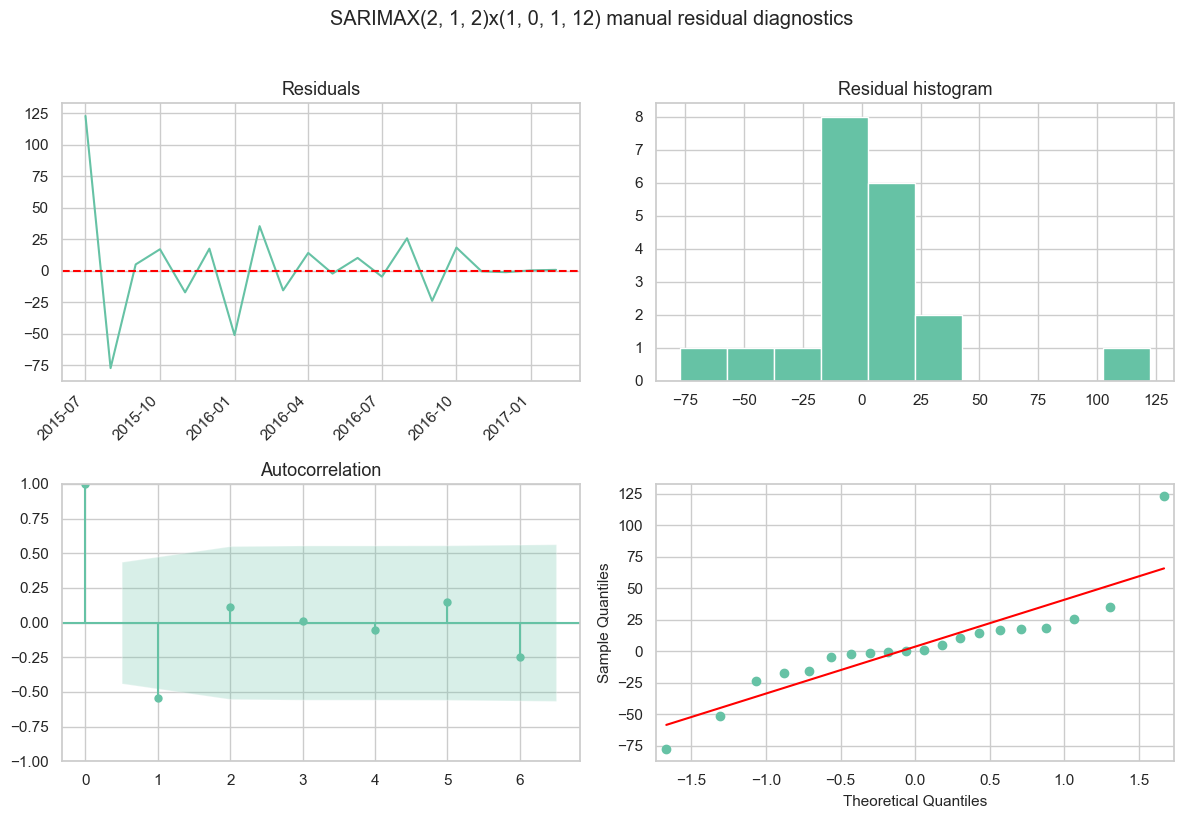

Ljung-Box on SARIMAX residuals:


,lb_stat,lb_pvalue
3,7.088756,0.069122
6,9.820844,0.132402
12,10.655424,0.558657


Ljung-Box on holt_trend residuals:


,lb_stat,lb_pvalue
3,3.337306,0.342484
6,7.221198,0.300875
12,19.789882,0.071167


,model,ljungbox_lag6_pvalue,ljungbox_lag12_pvalue,resid_mean,resid_std
0,SARIMAX,0.1324,0.5587,3.6247,38.1735
1,holt_trend,0.3009,0.0712,-0.0000,16.1023


In [9]:
resid = pd.Series(sarimax_train.resid, index=train.index).dropna()
diag_lags = max(4, min(8, len(resid) // 3))


def _format_resid_time_axis(ax) -> None:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")


try:
    fig = sarimax_train.plot_diagnostics(figsize=(12, 8), lags=diag_lags)
    fig.suptitle(f"SARIMAX{best_order}x{best_seasonal} residual diagnostics", y=1.02)
    _format_resid_time_axis(fig.axes[0])
    savefig("04_sarimax_diagnostics.png")
    plt.show()
except ValueError as e:
    print("plot_diagnostics skipped:", e)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(resid.index, resid.values)
    axes[0, 0].axhline(0, color="r", ls="--")
    axes[0, 0].set_title("Residuals")
    _format_resid_time_axis(axes[0, 0])
    axes[0, 1].hist(resid.values, bins=10, edgecolor="white")
    axes[0, 1].set_title("Residual histogram")
    plot_acf(resid, lags=diag_lags, ax=axes[1, 0])
    sm.qqplot(resid, line="s", ax=axes[1, 1])
    fig.suptitle(f"SARIMAX{best_order}x{best_seasonal} manual residual diagnostics", y=1.02)
    savefig("04_sarimax_diagnostics.png")
    plt.show()

lb_lags = [lag for lag in [3, 6, 12] if lag < len(resid)]
lb = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
print("Ljung-Box on SARIMAX residuals:")
display(lb)

hw_resid = pd.Series(train - hw_train.fittedvalues, index=train.index).dropna()
lb_hw = acorr_ljungbox(
    hw_resid, lags=[lag for lag in [3, 6, 12] if lag < len(hw_resid)], return_df=True
)
print(f"Ljung-Box on {hw_train_kind} residuals:")
display(lb_hw)


def lb_p(df, lag):
    return float(df.loc[lag, "lb_pvalue"]) if lag in df.index else np.nan


diag_summary = pd.DataFrame(
    {
        "model": ["SARIMAX", hw_train_kind],
        "ljungbox_lag6_pvalue": [lb_p(lb, 6), lb_p(lb_hw, 6)],
        "ljungbox_lag12_pvalue": [lb_p(lb, 12), lb_p(lb_hw, 12)],
        "resid_mean": [resid.mean(), hw_resid.mean()],
        "resid_std": [resid.std(), hw_resid.std()],
    }
)
display(diag_summary.round(4))
diag_summary.to_csv(FIG_DIR / "residual_diagnostics.csv", index=False)

## 6. Holdout evaluation + prediction intervals

So sánh trên 6 tháng cuối:
- Seasonal Naive: `ŷ_t = y_{t-12}`
- SARIMAX `get_forecast` → mean + 95% CI
- Holt–Winters `forecast`

In [10]:
def seasonal_naive(history: pd.Series, steps: int) -> np.ndarray:
    out, cur = [], history.astype(float).copy()
    for _ in range(steps):
        pred = float(cur.iloc[-SEASON]) if len(cur) >= SEASON else float(cur.mean())
        out.append(pred)
        cur = pd.concat([cur, pd.Series([pred], index=[cur.index[-1] + pd.offsets.MonthBegin(1)])])
    return np.asarray(out)


fc_naive = seasonal_naive(train, HOLDOUT)
fc_hw = np.asarray(hw_train.forecast(HOLDOUT), dtype=float)
hw_holdout_label = hw_train_kind

sarimax_fc = sarimax_train.get_forecast(steps=HOLDOUT)
fc_sarimax = np.asarray(sarimax_fc.predicted_mean, dtype=float)
ci_sarimax = sarimax_fc.conf_int(alpha=0.05)
ci_sarimax.columns = ["lower_95", "upper_95"]

holdout = pd.DataFrame(
    {
        "ym": test.index,
        "actual": test.values,
        "seasonal_naive": fc_naive,
        hw_holdout_label: fc_hw,
        "sarimax": fc_sarimax,
        "sarimax_lower95": ci_sarimax["lower_95"].values,
        "sarimax_upper95": ci_sarimax["upper_95"].values,
    }
)
for c in ["seasonal_naive", hw_holdout_label, "sarimax", "sarimax_lower95"]:
    holdout[c] = holdout[c].clip(lower=0)

display(holdout.round(2))

metrics = []
for name in ["seasonal_naive", hw_holdout_label, "sarimax"]:
    metrics.append(
        {
            "model": name,
            "MAE": mae(holdout["actual"], holdout[name]),
            "RMSE": rmse(holdout["actual"], holdout[name]),
            "MAPE": mape(holdout["actual"], holdout[name]),
        }
    )
metrics_df = pd.DataFrame(metrics).sort_values("MAPE").reset_index(drop=True)
display(metrics_df.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "MAPE": "{:.2%}"}))
metrics_df.to_csv(FIG_DIR / "holdout_metrics.csv", index=False)
holdout.to_csv(FIG_DIR / "holdout_forecast_detail.csv", index=False)

best_model = metrics_df.iloc[0]["model"]
print(f"Best holdout model (MAPE): {best_model}")
inside = (
    (holdout["actual"] >= holdout["sarimax_lower95"])
    & (holdout["actual"] <= holdout["sarimax_upper95"])
).mean()
print(f"SARIMAX 95% PI coverage on holdout: {inside:.1%}")

,ym,actual,seasonal_naive,holt_trend,sarimax,sarimax_lower95,sarimax_upper95
0,2017-03-01,84.09,77.09,77.36,87.48,86.12,88.85
1,2017-04-01,114.40,90.71,75.09,104.02,100.54,107.50
2,2017-05-01,118.82,100.62,72.82,116.00,111.32,120.67
3,2017-06-01,129.11,109.27,70.55,122.52,117.81,127.23
4,2017-07-01,146.56,132.72,68.28,136.90,132.02,141.78
5,2017-08-01,166.80,149.66,66.02,144.77,138.99,150.54


,model,MAE,RMSE,MAPE
0,sarimax,9.15,11.18,6.73%
1,seasonal_naive,16.62,17.42,13.24%
2,holt_trend,54.94,62.48,40.04%


Best holdout model (MAPE): sarimax
SARIMAX 95% PI coverage on holdout: 16.7%


Saved: reports\figures\18_adr\05_holdout_forecasts.png


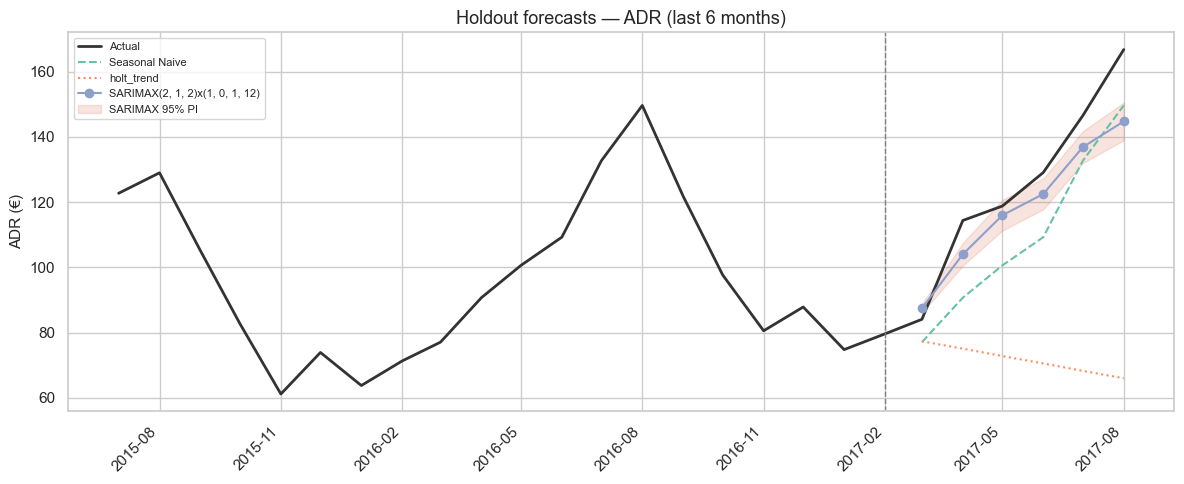

Saved: reports\figures\18_adr\05_holdout_metrics.png


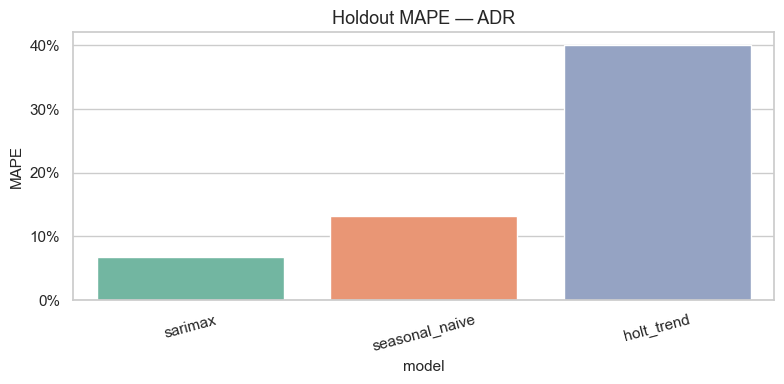


**Insight — holdout**

- MAPE: **sarimax** 6.7%, **seasonal_naive** 13.2%, **holt_trend** 40.0%.  
- Winner: **`sarimax`**.  
- SARIMAX 95% PI coverage: **17%**.  
- AIC trên train không đảm bảo thắng ngoài mẫu trên chuỗi ngắn → dùng **holdout winner** làm primary.


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
ax.plot(holdout["ym"], holdout["seasonal_naive"], ls="--", label="Seasonal Naive")
ax.plot(holdout["ym"], holdout[hw_holdout_label], ls=":", label=hw_holdout_label)
ax.plot(holdout["ym"], holdout["sarimax"], marker="o", label=f"SARIMAX{best_order}x{best_seasonal}")
ax.fill_between(
    holdout["ym"], holdout["sarimax_lower95"], holdout["sarimax_upper95"],
    color="#e07a5f", alpha=0.2, label="SARIMAX 95% PI",
)
ax.axvline(train.index.max(), color="gray", ls="--", lw=1)
ax.set_title(f"Holdout forecasts — {METRIC_LABEL} (last 6 months)")
ax.set_ylabel(YLABEL)
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
savefig("05_holdout_forecasts.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=metrics_df, x="model", y="MAPE", hue="model", legend=False, ax=ax)
ax.set_title(f"Holdout MAPE — {METRIC_LABEL}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.tick_params(axis="x", rotation=15)
savefig("05_holdout_metrics.png")
plt.show()

mape_lines = ", ".join(f"**{r.model}** {r.MAPE:.1%}" for r in metrics_df.itertuples())
ipy_display(Markdown(
    f"""
**Insight — holdout**

- MAPE: {mape_lines}.  
- Winner: **`{best_model}`**.  
- SARIMAX 95% PI coverage: **{inside:.0%}**.  
- AIC trên train không đảm bảo thắng ngoài mẫu trên chuỗi ngắn → dùng **holdout winner** làm primary.
"""
))

## 7. Refit full history + 6-month forecast (with CI)

Full-sample exponential smoothing kind: holt_winters_seasonal
                                      SARIMAX Results                                       
Dep. Variable:                                  adr   No. Observations:                   26
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 12)   Log Likelihood                 -29.153
Date:                              Mon, 20 Jul 2026   AIC                             72.306
Time:                                      09:05:05   BIC                             74.424
Sample:                                  07-01-2015   HQIC                            69.983
                                       - 08-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6042      1.516    

,ym,sarimax,sarimax_lower95,sarimax_upper95,holt_winters,holt_kind_full,seasonal_naive,best_holdout_model,sarimax_order,sarimax_seasonal_order
0,2017-09-01,143.36,136.93,149.79,136.49,holt_winters_seasonal,121.81,sarimax,"(2, 1, 2)","(1, 0, 1, 12)"
1,2017-10-01,116.77,110.12,123.41,113.21,holt_winters_seasonal,97.66,sarimax,"(2, 1, 2)","(1, 0, 1, 12)"
2,2017-11-01,91.44,83.60,99.29,93.90,holt_winters_seasonal,80.57,sarimax,"(2, 1, 2)","(1, 0, 1, 12)"
3,2017-12-01,100.52,92.61,108.44,103.91,holt_winters_seasonal,87.87,sarimax,"(2, 1, 2)","(1, 0, 1, 12)"
4,2018-01-01,87.95,79.73,96.17,92.31,holt_winters_seasonal,74.80,sarimax,"(2, 1, 2)","(1, 0, 1, 12)"
5,2018-02-01,96.53,87.95,105.11,98.50,holt_winters_seasonal,79.63,sarimax,"(2, 1, 2)","(1, 0, 1, 12)"


Saved: reports\figures\18_adr\07_forecast_horizon.png


<Figure size 1200x800 with 0 Axes>

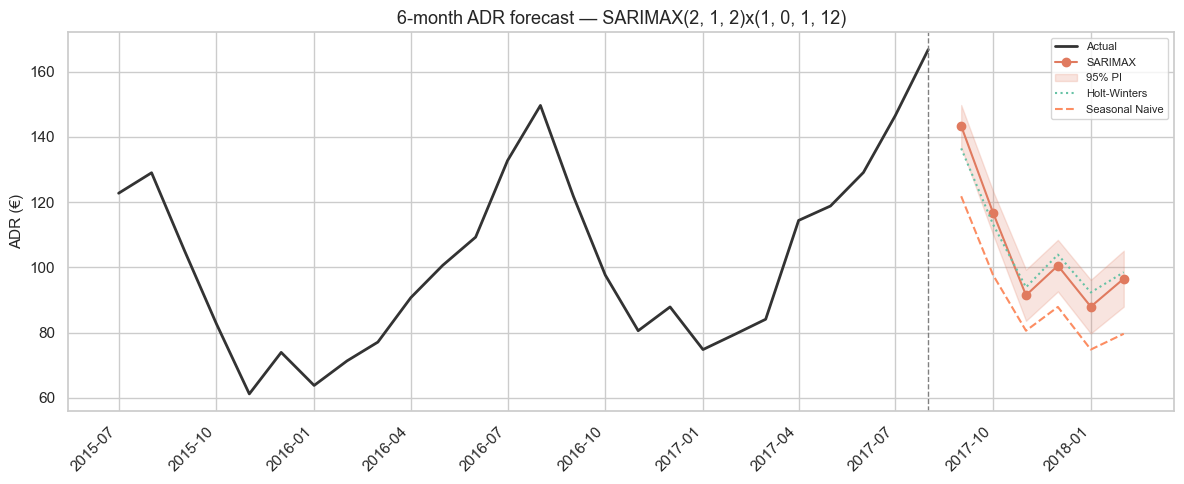

In [12]:
HORIZON = 6
sarimax_full = fit_sarimax(y, best_order, best_seasonal)
hw_full, hw_full_kind = fit_holt_winters(y, "full")
print(f"Full-sample exponential smoothing kind: {hw_full_kind}")
print(sarimax_full.summary())

full_resid_n = len(pd.Series(sarimax_full.resid).dropna())
full_lags = max(4, min(10, full_resid_n // 3))
try:
    fig = sarimax_full.plot_diagnostics(figsize=(12, 8), lags=full_lags)
    fig.suptitle(f"Full-sample SARIMAX diagnostics — {METRIC_LABEL}", y=1.02)
    savefig("06_sarimax_full_diagnostics.png")
    plt.show()
except ValueError as e:
    print("Full-sample plot_diagnostics skipped:", e)

fc_obj = sarimax_full.get_forecast(steps=HORIZON)
fc_mean = fc_obj.predicted_mean.clip(lower=0)
fc_ci = fc_obj.conf_int(alpha=0.05)
fc_ci.columns = ["lower_95", "upper_95"]
fc_ci["lower_95"] = fc_ci["lower_95"].clip(lower=0)
fc_hw = pd.Series(hw_full.forecast(HORIZON), index=fc_mean.index).clip(lower=0)
fc_naive = pd.Series(seasonal_naive(y, HORIZON), index=fc_mean.index)

forecast_df = pd.DataFrame(
    {
        "ym": fc_mean.index,
        "sarimax": fc_mean.values,
        "sarimax_lower95": fc_ci["lower_95"].values,
        "sarimax_upper95": fc_ci["upper_95"].values,
        "holt_winters": fc_hw.values,
        "holt_kind_full": hw_full_kind,
        "seasonal_naive": fc_naive.values,
        "best_holdout_model": best_model,
        "sarimax_order": str(best_order),
        "sarimax_seasonal_order": str(best_seasonal),
    }
)
display(forecast_df.round(2))
forecast_df.to_csv(FIG_DIR / "forecast_next_6m.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
ax.plot(forecast_df["ym"], forecast_df["sarimax"], marker="o", color="#e07a5f", label="SARIMAX")
ax.fill_between(
    forecast_df["ym"], forecast_df["sarimax_lower95"], forecast_df["sarimax_upper95"],
    color="#e07a5f", alpha=0.2, label="95% PI",
)
ax.plot(forecast_df["ym"], forecast_df["holt_winters"], ls=":", label="Holt-Winters")
ax.plot(forecast_df["ym"], forecast_df["seasonal_naive"], ls="--", label="Seasonal Naive")
ax.axvline(y.index.max(), color="gray", ls="--", lw=1)
ax.set_title(f"6-month {METRIC_LABEL} forecast — SARIMAX{best_order}x{best_seasonal}")
ax.set_ylabel(YLABEL)
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
savefig("07_forecast_horizon.png")
plt.show()

## 8. Rate / revenue stance

Ghép forecast (model thắng holdout) với seasonal index:
- `combined_pressure >= 1.15` → PROTECT  
- `combined_pressure <= 0.90` → STIMULATE  
- else → NEUTRAL  

| Stance | Ý nghĩa (ADR) |
|--------|----------------------------------|
| PROTECT | PROTECT — harden BAR / limit discounting |
| STIMULATE | STIMULATE — promo / early-bird / package |
| NEUTRAL | NEUTRAL — hold BAR, tactical weekend premium |

,ym,forecast_model,forecast,season_index,metric_index,combined_pressure,pricing_stance
0,2017-09-01,sarimax,143.363,1.140,1.440,1.290,PROTECT — harden BAR / limit discounting
1,2017-10-01,sarimax,116.765,0.906,1.173,1.039,"NEUTRAL — hold BAR, tactical weekend premium"
2,2017-11-01,sarimax,91.445,0.712,0.918,0.815,STIMULATE — promo / early-bird / package
3,2017-12-01,sarimax,100.524,0.812,1.010,0.911,"NEUTRAL — hold BAR, tactical weekend premium"
4,2018-01-01,sarimax,87.953,0.696,0.883,0.790,STIMULATE — promo / early-bird / package
5,2018-02-01,sarimax,96.528,0.758,0.970,0.864,STIMULATE — promo / early-bird / package


Saved: reports\figures\18_adr\08_pricing_stance.png


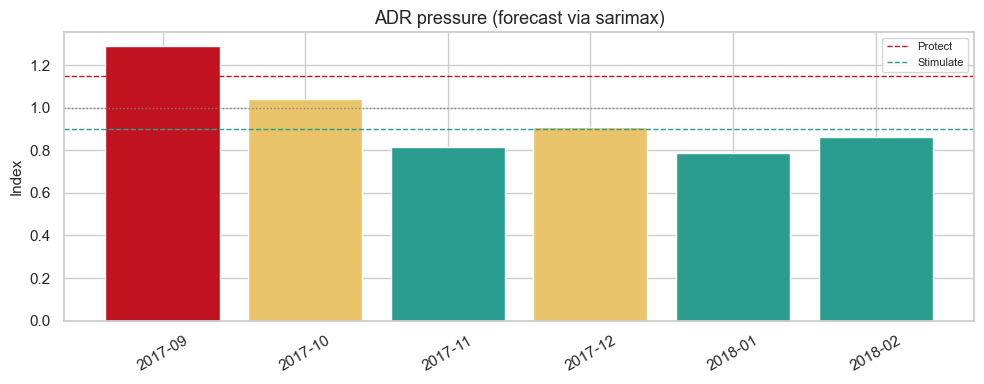

In [13]:
month_mean = y.groupby(y.index.month).mean()
season_index = (month_mean / month_mean.mean()).rename("season_index")

if best_model == "seasonal_naive":
    fc_col = "seasonal_naive"
elif best_model == "sarimax":
    fc_col = "sarimax"
else:
    fc_col = "holt_winters"

grand = float(month_mean.mean())
pricing = forecast_df[["ym", fc_col]].copy().rename(columns={fc_col: "forecast"})
pricing["month"] = pricing["ym"].dt.month
pricing["season_index"] = pricing["month"].map(season_index)
pricing["metric_index"] = pricing["forecast"] / grand
pricing["combined_pressure"] = 0.5 * pricing["season_index"] + 0.5 * pricing["metric_index"]

STANCE_HIGH = "PROTECT — harden BAR / limit discounting"
STANCE_LOW = "STIMULATE — promo / early-bird / package"
STANCE_MID = "NEUTRAL — hold BAR, tactical weekend premium"


def stance(row) -> str:
    if row["combined_pressure"] >= 1.15:
        return STANCE_HIGH
    if row["combined_pressure"] <= 0.90:
        return STANCE_LOW
    return STANCE_MID


pricing["pricing_stance"] = pricing.apply(stance, axis=1)
pricing["forecast_model"] = best_model
cols = [
    "ym", "forecast_model", "forecast", "season_index",
    "metric_index", "combined_pressure", "pricing_stance",
]
display(pricing[cols].round(3))
pricing[cols].to_csv(FIG_DIR / "pricing_stance_forecast.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = pricing["pricing_stance"].map(
    {STANCE_HIGH: "#c1121f", STANCE_LOW: "#2a9d8f", STANCE_MID: "#e9c46a"}
)
ax.bar(pricing["ym"].dt.strftime("%Y-%m"), pricing["combined_pressure"], color=colors)
ax.axhline(1.15, color="#c1121f", ls="--", lw=1, label="Protect")
ax.axhline(0.90, color="#2a9d8f", ls="--", lw=1, label="Stimulate")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_title(f"{METRIC_LABEL} pressure (forecast via {best_model})")
ax.set_ylabel("Index")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)
savefig("08_pricing_stance.png")
plt.show()

## 9. KPI summary & insights

In [14]:
mape_map = metrics_df.set_index("model")["MAPE"].to_dict()
insights = [
    f"- Skill: statsmodels Workflow 4 (ADF/KPSS → ACF/PACF → SARIMAX AIC → diagnostics → forecast CI).",
    f"- Target: {METRIC_LABEL} — monthly mean ADR (stay bookings, adr > 0).",
    f"- Series: {len(y)} months; mean={fmt_num(y.mean(), 2)}; d={d_order}, D={D_order}.",
    f"- Best SARIMAX (train AIC): {best_order} x {best_seasonal} (AIC={best['aic']:.1f}).",
    f"- Holdout MAPE: " + ", ".join(f"{k}={v:.1%}" for k, v in mape_map.items()),
    f"- Best holdout model: **{best_model}**.",
    f"- SARIMAX 95% PI holdout coverage: {inside:.1%}.",
    "- Chuỗi ngắn (~26 điểm) → ưu tiên holdout + residual diagnostics, không chỉ AIC.",
]

print("=" * 72)
print(f"{METRIC_LABEL} FORECASTING INSIGHTS (statsmodels)")
print("=" * 72)
for line in insights:
    print(line)

kpi = pd.DataFrame(
    [
        {"metric": "n_months", "value": len(y)},
        {"metric": "mean_adr_history", "value": round(float(y.mean()), 4)},
        {"metric": "diff_d", "value": d_order},
        {"metric": "diff_D", "value": D_order},
        {"metric": "sarimax_order", "value": str(best_order)},
        {"metric": "sarimax_seasonal_order", "value": str(best_seasonal)},
        {"metric": "sarimax_aic_train", "value": round(float(best["aic"]), 2)},
        {"metric": "best_holdout_model", "value": best_model},
        {"metric": "best_holdout_mape", "value": round(float(metrics_df.iloc[0]["MAPE"]), 4)},
        {"metric": "naive_holdout_mape", "value": round(float(mape_map.get("seasonal_naive", np.nan)), 4)},
        {"metric": "hw_holdout_kind", "value": hw_holdout_label},
        {"metric": "sarimax_holdout_mape", "value": round(float(mape_map.get("sarimax", np.nan)), 4)},
        {"metric": "sarimax_pi95_coverage", "value": round(float(inside), 4)},
        {"metric": "forecast_horizon_months", "value": HORIZON},
        {"metric": "statsmodels_version", "value": sm.__version__},
        {"metric": "formula_note", "value": "RevPAR = ADR × Occupancy_Rate (proxy)"},
    ]
)
display(kpi)
kpi.to_csv(FIG_DIR / "kpi_summary.csv", index=False)
print(f"Saved KPI: {(FIG_DIR / 'kpi_summary.csv').relative_to(ROOT)}")

ADR FORECASTING INSIGHTS (statsmodels)
- Skill: statsmodels Workflow 4 (ADF/KPSS → ACF/PACF → SARIMAX AIC → diagnostics → forecast CI).
- Target: ADR — monthly mean ADR (stay bookings, adr > 0).
- Series: 26 months; mean=102,77; d=1, D=0.
- Best SARIMAX (train AIC): (2, 1, 2) x (1, 0, 1, 12) (AIC=23.1).
- Holdout MAPE: sarimax=6.7%, seasonal_naive=13.2%, holt_trend=40.0%
- Best holdout model: **sarimax**.
- SARIMAX 95% PI holdout coverage: 16.7%.
- Chuỗi ngắn (~26 điểm) → ưu tiên holdout + residual diagnostics, không chỉ AIC.


,metric,value
0,n_months,26
1,mean_adr_history,102.77
2,diff_d,1
3,diff_D,0
4,sarimax_order,"(2, 1, 2)"
5,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,sarimax_aic_train,23.09
7,best_holdout_model,sarimax
8,best_holdout_mape,0.0673
9,naive_holdout_mape,0.1324


Saved KPI: reports\figures\18_adr\kpi_summary.csv
